# ShiftScope

**Compare any two single-cell populations**, measure how far the cell-state
distribution shifts, localize *where*, find the *driver genes*, and let Claude
interpret the biology. Condition-agnostic: control vs perturbation, disease vs
healthy, young vs old, cell type vs cell type — one tool.

This notebook's worked example is **control vs IFN-β-stimulated monocytes**
(Kang 2018). It downloads a 38 MB dataset and runs in ~20 s on CPU.

In [ ]:
# === Colab setup — Runtime > Run all (skip this cell if running locally from a clone) ===
# The repo must be PUBLIC (Colab can't clone a private repo over https).
# Installs only what Colab lacks, PINNING numpy+pandas to Colab's existing versions so nothing
# is upgraded — that's what avoids the numpy ABI break that would otherwise need a restart.
# (If cell 2 ever still fails to import: Runtime > Restart session, then Run all again.)
![ -d /content/claude_science_hackathon ] || git clone -q https://github.com/aenorhabditis6/claude_science_hackathon.git /content/claude_science_hackathon
%cd /content/claude_science_hackathon
import numpy, pandas
!pip install -q "numpy=={numpy.__version__}" "pandas=={pandas.__version__}" scanpy anndata pot umap-learn leidenalg igraph s3fs h5py anthropic gradio 'typing_extensions>=4.15'
print('Setup done. Now: Runtime > Run all.  (No restart needed. If an import fails: Restart session, then Run all.)')

In [3]:
import sys, os
sys.path.insert(0, '.')  # so `from shiftscope import ...` works from the repo root
# On Colab, pull the API key from Secrets (the 🔑 icon in the sidebar) if you added one named
# ANTHROPIC_API_KEY. Enables §7 + §8c Claude features; without it they degrade gracefully.
try:
    from google.colab import userdata
    os.environ.setdefault('ANTHROPIC_API_KEY', userdata.get('ANTHROPIC_API_KEY'))
except Exception:
    pass  # not on Colab, or no secret set
from shiftscope import io, embed, compare, localize, drivers, interpret
import scanpy as sc
sc.settings.verbosity = 1

## 1. Load — control vs IFN-β-stimulated monocytes (Kang 2018)

`load_public` fetches a ready-made dataset and tags a `(reference, query)` pair. The
`within=` argument first restricts to one subpopulation, so we compare ctrl vs stim
*inside* monocytes. Any local file works the same way via `io.load(path, key, ref, query)`.

In [4]:
adata = io.load_public('kang', 'ctrl', 'stim', within=('cell_type', 'CD14+ Monocytes'))
print(adata)
adata.obs['_group'].value_counts()

AnnData object with n_obs × n_vars = 5697 × 2000
    obs: 'nCount_RNA', 'nFeature_RNA', 'tsne1', 'tsne2', 'label', 'cluster', 'cell_type', 'replicate', 'nCount_SCT', 'nFeature_SCT', 'integrated_snn_res.0.4', 'seurat_clusters', '_group'
    var: 'name', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: '_reference', '_query', '_condition_key', 'log1p', 'hvg'
    obsm: 'X_pca', 'X_umap'


,count
_group,
ctrl,2932
stim,2765


## 2. Embed — one shared PCA on the pooled cells, plus a 2D UMAP

In [5]:
Z_ref, Z_query = embed.embed(adata, n_pcs=30)
print('Z_ref', Z_ref.shape, ' Z_query', Z_query.shape)

/usr/lib/python3.12/functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


Z_ref (2932, 30)  Z_query (2765, 30)


## 3. Compare — E-distance + E-test (scPerturb), MMD, Sinkhorn-OT

The E-distance and its permutation E-test are the scPerturb / pertpy standard for how
strongly a perturbation shifts a population. Expect a large distance and a tiny p-value.

In [6]:
result = compare.distances(Z_ref, Z_query, n_sub=500, n_perm=1000)
for k, v in result.items():
    print(f'{k:>10}: {v}')

 edistance: 215.65288805493208
   p_value: 0.000999000999000999
  sinkhorn: 0.12567226443284835
       mmd: 0.347115583960816
     n_ref: 2932
   n_query: 2765
     n_sub: 500
    n_perm: 1000


## 4. UMAP colored by group

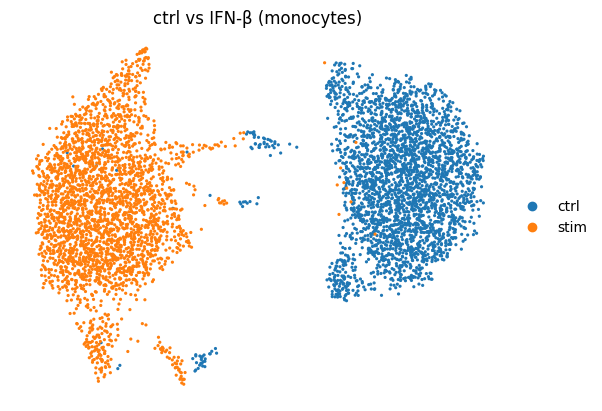

In [7]:
sc.pl.umap(adata, color='_group', title='ctrl vs IFN-β (monocytes)', frameon=False)

## 5. Localize — which clusters gained/lost query cells

Leiden-cluster the shared latent, then test each cluster's ctrl/stim composition
(Fisher exact + BH). Clusters flagged `gained`/`lost` are the localized shift.

In [8]:
shift_table = localize.localize(adata, resolution=1.0)
shift_table[['cluster', 'n_ref', 'n_query', 'log2_enrichment', 'qval', 'direction']]

,cluster,n_ref,n_query,log2_enrichment,qval,direction
0,0,909,0,-11.279617,1.161805e-297,lost
1,10,0,319,9.581084,7.568714e-105,gained
2,9,5,1338,8.963148,0.000000e+00,gained
3,8,3,832,8.493391,3.885214e-287,gained
4,6,142,0,-8.141835,3.070493e-42,lost
5,1,1276,8,-7.965738,0.000000e+00,lost
6,2,297,1,-7.700725,3.045427e-87,lost
7,11,3,141,5.495915,8.053497e-41,gained
8,3,222,5,-5.364601,3.981180e-58,lost
9,5,25,47,0.994399,5.194079e-03,gained


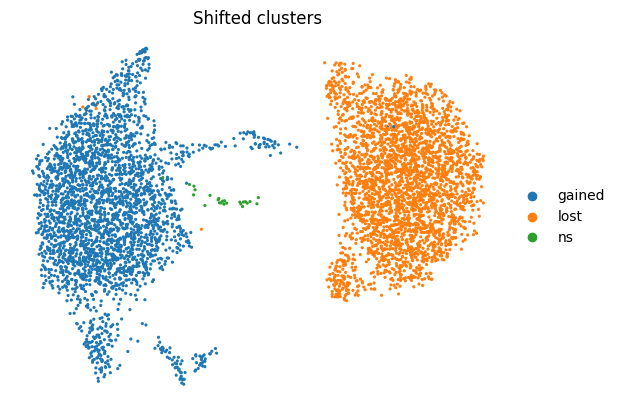

In [9]:
sc.pl.umap(adata, color='_shift', title='Shifted clusters', frameon=False)

## 6. Drivers — Wilcoxon DE (should surface interferon-stimulated genes)

Expect ISG15, IFI6, IFIT1/3, MX1, OAS1, CXCL10 — the textbook type-I interferon response.

In [10]:
drv = drivers.drivers(adata)
print('Up in stim  :', ', '.join(drv['up']['gene'].head(15)))
print('Down in stim:', ', '.join(drv['down']['gene'].head(10)))

Up in stim  : ISG15, IFITM3, ISG20, APOBEC3A, TNFSF10, LY6E, IFIT3, CXCL10, RSAD2, IFI6, IFIT1, IFIT2, IDO1, CXCL11, MX1
Down in stim: FTH1, IL8, PFN1, RPL7, ACTB, OAZ1, RPL6, RPL15, RPL10, GAPDH


## 7. Interpret — Claude turns the numbers into a cited rationale

Needs `ANTHROPIC_API_KEY`. We hand Claude only the structured evidence and log the
exact prompt + inputs, so every claim traces back to a number.

In [11]:
# import os; os.environ['ANTHROPIC_API_KEY'] = 'sk-ant-...'   # set your key
evidence = interpret.assemble_evidence(adata, result, shift_table, drv)
record = interpret.interpret(evidence)
print(record['output'])

**1. Is the shift real, and how large?**
Yes — this is a large, highly significant shift. E-distance = 215.7 (p = 0.001, permutation test), MMD = 0.35, and Sinkhorn = 0.126 all indicate substantial redistribution of cell states between ctrl and stim, well beyond noise.

**2. Where it localizes in cell-state space**
The shift is not diffuse — it's concentrated in discrete cluster reassignments, essentially a near-complete relabeling of cell states:
- Cluster 0 is essentially eliminated (log2 enrichment −11.28, 909→0 cells, q=1.2e-297).
- Clusters 1, 2, 3, 6 are similarly depleted (log2 enrichment −7.97 to −5.36, qvals ≤3.98e-58), together accounting for ~1900 reference cells that disappear in stim.
- New states 9, 8, 10 appear de novo (log2 enrichment +8.96, +8.49, +9.58; 1338, 832, and 319 cells respectively, q≈0 to 3.9e-287), with a smaller gain in cluster 11 (+5.5, 141 cells).
- Clusters 4 and 5 show only marginal enrichment (+0.68, +0.99, q~0.005–0.03) — likely unaffected or transit

## 8. Same tool, every domain (this is the point)

Nothing above is specific to interferon or to monocytes. The identical three-line pipeline
runs across **immunology, host–pathogen disease, developmental biology, and cell-type ID** —
and recovers the *correct, distinct* biology each time. Same code, four different fields.

In [12]:
def shiftscope(adata):
    Zr, Zq = embed.embed(adata, run_umap=False)
    d = compare.distances(Zr, Zq, n_sub=500, n_perm=500)
    up = drivers.drivers(adata)['up']['gene'].head(8).tolist()
    return d['edistance'], d['p_value'], up

cases = [
    ('immune — mouse phagocytes: unst vs LPS',   io.load_public('hagai', 'unst', 'LPS6', within=('species', 'mouse'))),
    ('disease — gut: healthy vs H. polygyrus',   io.load_public('haber', 'Control', 'Hpoly.Day10')),
    ('development — blood: monocyte vs erythroid', io.load_public('paul15', '14Mo', '2Ery')),
    ('cell types — pbmc68k: Monocyte vs B cell',  io.load_public('pbmc68k', 'CD14+ Monocyte', 'CD19+ B')),
]
for name, ad in cases:
    e, p, up = shiftscope(ad)
    print(f'{name:44s}  E-dist={e:8.1f}  p={p:.3f}  top: {", ".join(up[:6])}')
# Expect: LPS->Ccl3/4/Il1a (NF-κB); infection->Reg3b/g,Defa (antimicrobial);
#         erythroid->Klf1,Car2 (master TF); Monocyte->TYROBP,S100A8 (myeloid). Distinct each time.

  0%|          | 0.00/9.82M [00:00<?, ?B/s]

/usr/lib/python3.12/functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


immune — mouse phagocytes: unst vs LPS        E-dist=   825.8  p=0.002  top: Ccl3, Sod2, Ccl5, Il1a, Ccl4, Isg15
disease — gut: healthy vs H. polygyrus        E-dist=    81.1  p=0.002  top: Defa24, Gm15284, Reg3b, Reg3g, Gpx2, Cd74
development — blood: monocyte vs erythroid    E-dist=  1308.8  p=0.002  top: Fam132a, Car2, Blvrb, Mt2, Klf1, Ermap


/usr/local/lib/python3.12/dist-packages/scanpy/preprocessing/_scale.py:192: RuntimeWarning: invalid value encountered in sqrt
  std = np.sqrt(var)


cell types — pbmc68k: Monocyte vs B cell      E-dist=   288.3  p=0.002  top: CD79A, PTPRCAP, CYTL1, CD40LG, GATA2, AKR1C3


/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:483: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(


## 8b. Rank many conditions by effect size

`compare.rank()` orders every condition by how far it moves the population — the core
Perturb-seq question, "which perturbation does the most?" On Dong 2023 it correctly ranks
IFNβ+IFNγ > IFNβ > IFNγ. On the Marson screen, the same call ranks every gene knockdown.

In [13]:
# rank(): order many conditions by how far each shifts the population
# (the core Perturb-seq question — "which perturbation does the most?")
dong = io._preprocess_if_needed(io._fetch_public(io.PUBLIC_DATASETS['dong']))
compare.rank(dong, 'perturbation', 'No stimulation')  # IFNb+IFNg > IFNb > IFNg

,query,edistance,p_value,mmd,n_query
0,IFNb+ IFNg,99.963996,0.004975,0.090889,2238
1,IFNb,73.445024,0.004975,0.075628,2759
2,IFNg,35.745111,0.004975,0.030534,1944


**Rank a real CRISPR screen.** The same `rank()` call, on the Shifrut 2018 human CD8 T-cell
screen — 20 knockouts, ± TCR stimulation (Marson lab). It recovers the actual biology: the
TCR-signaling core (**LCP2/SLP-76, CD3D**) shifts cells most, followed by the **negative
regulators (RASA2, CBLB, SOCS1, TCEB2)** that paper found *enhance* T-cell function — the
same class of immunotherapy targets. A second real screen, no cell streaming.

In [14]:
import numpy as np
# KO effects show under stimulation -> restrict to stim, annotated cells; rank all KOs vs control.
sh = io._fetch_public(io.PUBLIC_DATASETS['shifrut'])
sh = sh[(sh.obs['perturbation_2'].astype(str) == 'stim') & sh.obs['perturbation'].notna()].copy()
pert = sh.obs['perturbation'].astype(str).values
rng = np.random.default_rng(0)                        # cap 250 cells/KO for a fast live demo
keep = []
for g in np.unique(pert):
    gi = np.where(pert == g)[0]
    keep.append(gi if len(gi) <= 250 else rng.choice(gi, 250, replace=False))
sh = io._preprocess_if_needed(sh[np.sort(np.concatenate(keep))].copy())
compare.rank(sh, 'perturbation', 'control').head(10)  # LCP2/CD3D core + RASA2/CBLB/SOCS1 regulators

/usr/lib/python3.12/functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


,query,edistance,p_value,mmd,n_query
0,LCP2,9.550903,0.004975,0.011207,250
1,TCEB2,7.393268,0.009950,0.008072,250
2,CBLB,6.762699,0.009950,0.007210,250
3,CD3D,6.654544,0.009950,0.008382,250
4,RASA2,6.430223,0.019900,0.006959,250
5,CD5,6.344491,0.014925,0.007057,250
6,SOCS1,5.452006,0.029851,0.005708,250
7,ARID1A,5.258954,0.064677,0.005911,250
8,BTLA,5.173738,0.019900,0.005866,250
9,DGKA,4.679281,0.039801,0.005802,250


## 8c. Prioritize — which hits deserve a validation experiment?

Ranking hits by effect size isn't enough: the top of any screen is dominated by genes we
already understand. The decision a scientist actually faces is *which strong hit is worth
bench time* — and that means **strong phenotype × under-studied**.

`prioritize.py` scores both axes on the **real Marson CD4+ T-cell screen** (11k knockdowns,
`DE_stats.suppl_table.csv` — no cell streaming needed). The under-studied axis is
**grounded**, not guessed: a live NCBI PubMed query counts how many papers discuss each gene
in T-cell / immune biology. Then Claude scores novelty (1–5) and gives a validate/skip
verdict — with the real paper count in front of it, so every call traces back to data.

Watch the tool sink the textbook genes (**VAV1**, **CD45/PTPRC** — hundreds of papers) and
surface strong-but-obscure chromatin regulators (**TADA2B**, **SGF29**, **ELOF1** — 0–4
papers) as the "validate these" shortlist.

In [15]:
from shiftscope import prioritize

# End-to-end: Marson hits -> live PubMed grounding -> Claude verdict -> ranked shortlist.
# Needs ANTHROPIC_API_KEY for the novelty/verdict columns; without it you still get the
# grounded phenotype + PubMed ranking and the figure.
shortlist = prioritize.prioritize(condition='Stim48hr', top_n=20)
shortlist[['gene', 'phenotype', 'pubmed_count', 'priority_score',
           'novelty', 'recommendation', 'verdict']]

7193 hits in Stim48hr; scoring top 20 by phenotype.
  [pubmed 1/20] TADA2B: 1
  [pubmed 2/20] SGF29: 4
  [pubmed 3/20] ELOF1: 1
  [pubmed 4/20] CCNC: 14
  [pubmed 5/20] SUPT7L: 2
  [pubmed 6/20] VAV1: 564
  [pubmed 7/20] PMVK: 9
  [pubmed 8/20] TAF6L: 0
  [pubmed 9/20] ATAD5: 10
  [pubmed 10/20] SUPT20H: 4
  [pubmed 11/20] DOP1B: 0
  [pubmed 12/20] PTPRC: 790
  [pubmed 13/20] LAT: 1260
  [pubmed 14/20] TADA1: 1
  [pubmed 15/20] BCL10: 356
  [pubmed 16/20] TFAM: 142
  [pubmed 17/20] ARNT: 197
  [pubmed 18/20] KDM1A: 121
  [pubmed 19/20] SENP5: 7
  [pubmed 20/20] RPRD2: 2


,gene,phenotype,pubmed_count,priority_score,novelty,recommendation,verdict
0,TADA2B,5260.0,1,3.659358,5,prioritize,Top-ranked phenotype paired with almost no pri...
1,SGF29,4869.0,4,2.670686,5,prioritize,Very strong effect with minimal published char...
2,ELOF1,4258.0,1,2.131347,5,prioritize,Strong phenotype on a gene essentially unstudi...
3,TAF6L,3486.0,0,1.250925,5,prioritize,Zero prior papers with a strong knockout effec...
4,SUPT7L,3645.0,2,1.022900,5,prioritize,Large effect with very sparse prior study—like...
5,CCNC,4091.0,14,1.013772,3,maybe,Strong effect but moderate existing literature...
6,DOP1B,3241.0,0,0.877310,5,prioritize,"No prior papers found, yet a sizable phenotype..."
7,TADA1,3114.0,1,0.386791,5,prioritize,Strong effect on a gene with almost no immune-...
8,PMVK,3528.0,9,0.328864,4,prioritize,Strong phenotype and low publication count in ...
9,SUPT20H,3312.0,4,0.296321,5,prioritize,Strong phenotype with minimal characterization...


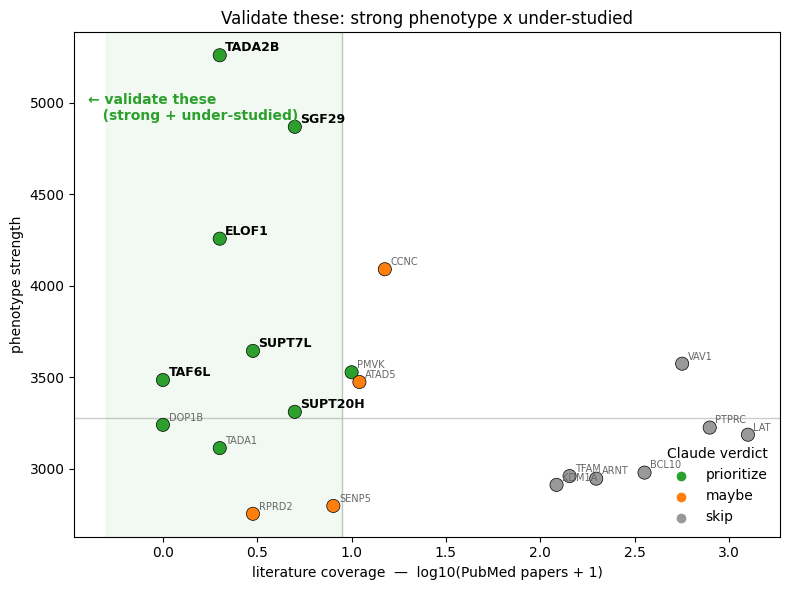

In [16]:
# The money figure: phenotype strength (y) vs literature coverage (x).
# Top-LEFT quadrant = strong + under-studied = the hits to validate.
prioritize.plot(shortlist);

## 8d. Calibration — when does it work? (operating boundaries)

A distance-with-a-p-value is only trustworthy if you know where it breaks. `calibration.py`
stress-tests the E-test on the *known* Kang IFN-β shift and maps two limits, reporting
**power** (fraction of random draws reaching p<0.05) over many repeats — not one lucky call:

- **vs cell number** — subsample down to 10 cells/group (on a deliberately subtle shift, so
  cell count is the limiting factor). Power collapses below ~100 cells/group.
- **vs effect size** — dilute the query with reference cells until the shift vanishes. It
  stays detectable until ~90% of the query is reference cells (the minimum detectable shift).

This is the honest "here's the envelope" figure — exactly the rigor a reviewer asks for.
Takes ~20 s.

/usr/lib/python3.12/functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


calibrating on 2932 ref + 2765 query cells in 30 PCs
Cell number: on a subtle shift (query 85%-diluted), reliable detection (power ≥ 80%) needs ~100 cells/group. Effect size: at n=200 cells/group the shift is still detected when up to ~90% of the query is reference cells — the minimum detectable shift.


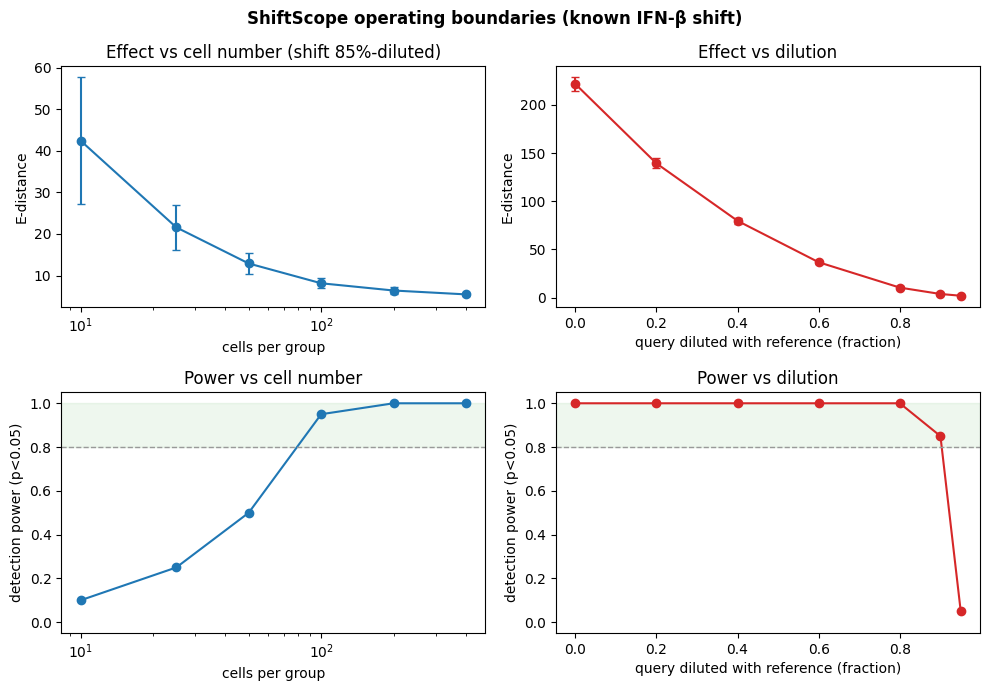

In [17]:
from shiftscope import calibration

# verbose=True prints the one-line envelope summary itself; loads Kang monocytes, runs both sweeps
cal = calibration.calibrate(reps=20, n_perm=200)
calibration.plot(cal['cells'], cal['effect']);

## 9. (Advanced) Genome-scale streaming — Marson CRISPRi Perturb-seq

`load_demo` streams a subsample straight from the 140 GB remote h5ad (GEO GSE314342) —
never downloading it whole. Fast on Colab; slow on a high-latency link. Uncomment to run
NTC vs a SETDB1 knockdown in resting CD4+ T cells.

In [18]:
# adata_m = io.load_demo(query='SETDB1', condition='Rest', n_per_group=300)
# Zr, Zq = embed.embed(adata_m)
# print(compare.distances(Zr, Zq))